# Integrating Pandas with Matplotlib

In real-world software engineering and data science, we rarely write raw datasets by hand. Instead, we load them from database files, APIs, or **CSV** (Comma-Separated Values) files.

To load and clean tabular data (data organized in rows and columns), Python developers use a library called **Pandas**.
*   **Pandas** is built on top of NumPy.
*   It organizes data into objects called **DataFrames** (which are like Excel spreadsheets or TypeScript tables of objects).
*   Because Pandas is built on NumPy, Matplotlib understands Pandas perfectly! We can take columns directly from Pandas and plot them with Matplotlib with zero friction.

We will learn how to load a dataset, count category frequencies using `.value_counts()`, and render a beautiful horizontal bar chart (`plt.barh()`).

### Simple Explanation with an Everyday Analogy
Imagine you have a large box containing hundreds of mixed colored LEGO bricks.
*   **Pandas** is your super-fast assistant who dumps the box onto a table, sorts the bricks by color, and counts exactly how many of each color you have (e.g., 28 Red, 22 Yellow, 14 Blue).
*   **Matplotlib** is the artist who takes those counts from your assistant and draws a colorful bar chart on a board so you can see the color distribution instantly.

### Code Examples

Let's see how this works in Python. We will first simulate a CSV dataset of characters (similar to a Pokémon or game-character stats table) and analyze it.


#### Loading and Counting with Pandas, Plotting with Matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Simulate a loaded dataset of characters
data = {
    'Name': ['Pikachu', 'Charizard', 'Squirtle', 'Bulbasaur', 'Gengar', 'Eevee', 'Mewtwo', 'Snorlax', 'Dragonite', 'Arcanine'],
    'Type 1': ['Electric', 'Fire', 'Water', 'Grass', 'Ghost', 'Normal', 'Psychic', 'Normal', 'Dragon', 'Fire'],
    'HP': [35, 78, 44, 45, 60, 55, 106, 160, 91, 90]
}
df = pd.DataFrame(data)

print("--- DataFrame loaded ---")
print(df.head(3)) # Show first 3 rows

# Count how many characters belong to each Type 1 category
type_counts = df['Type 1'].value_counts()
print("\n--- Type Counts ---")
print(type_counts)

--- DataFrame loaded ---
        Name    Type 1  HP
0    Pikachu  Electric  35
1  Charizard      Fire  78
2   Squirtle     Water  44

--- Type Counts ---
Type 1
Fire        2
Normal      2
Electric    1
Water       1
Grass       1
Ghost       1
Psychic     1
Dragon      1
Name: count, dtype: int64


Now we can take `type_counts.index` (the names of the types) and `type_counts.values` (the count numbers) and plot them directly!


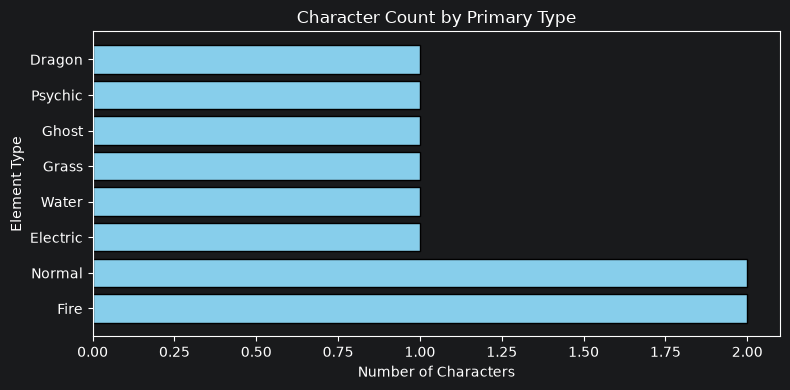

In [2]:
import matplotlib.pyplot as plt

# Setup the horizontal bar plot
plt.figure(figsize=(8, 4))
plt.barh(type_counts.index, type_counts.values, color='skyblue', edgecolor='black')

# Labeling
plt.title("Character Count by Primary Type")
plt.xlabel("Number of Characters")
plt.ylabel("Element Type")
plt.tight_layout()

# In a real environment, you call: plt.show()

### Common Mistakes Beginners Make
1.  **Forgetting parentheses on `.value_counts()`**: Writing `df['Column'].value_counts` without the `()` will return the method itself rather than executing the count.
2.  **Using `.bar()` instead of `.barh()` for long text labels**: When your categories have long names, putting them on the X-axis (`.bar()`) makes them crowd together and become unreadable. Always prefer `.barh()` for text categories.
3.  **Forgetting to call `.tight_layout()`**: When using Pandas indices as labels, they can sometimes be cut off at the edge of the image. Always call `plt.tight_layout()` to autospace the canvas.


#### Exercise 1 (Easy)
Write a Python code block using Pandas and Matplotlib to:
1. Create a Series with values `[10, 20, 20, 30, 10, 10]` and index representing programming languages `['TypeScript', 'Python', 'Python', 'TypeScript', 'TypeScript', 'TypeScript']`.
2. Compute the value counts.
3. Draw a vertical bar chart of the counts.

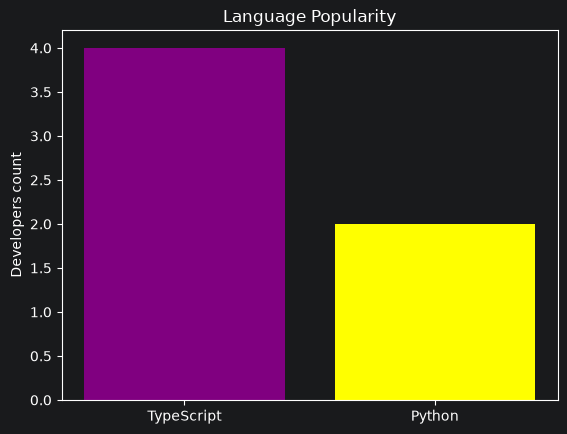

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

languages = pd.Series(['TypeScript', 'Python', 'Python', 'TypeScript', 'TypeScript', 'TypeScript'])
counts = languages.value_counts()

plt.bar(counts.index, counts.values, color=['purple', 'yellow'])
plt.title("Language Popularity")
plt.ylabel("Developers count")
plt.show()

#### Exercise 2 (Medium)
You have a DataFrame of software developers:
```python
data = {
    'Name': ['Alex', 'John', 'Sarah', 'Emily', 'David'],
    'Language': ['TypeScript', 'TypeScript', 'Python', 'TypeScript', 'Python'],
    'Salary': [80000, 95000, 110000, 85000, 105000]
}
```
1. Filter the DataFrame to keep only developers who use `'TypeScript'`.
2. Compute their average salary using `.mean()` on the Salary column.
3. Compare it with the average salary of `'Python'` developers.


In [4]:
import pandas as pd
data = {
    'Name': ['Alex', 'John', 'Sarah', 'Emily', 'David'],
    'Language': ['TypeScript', 'TypeScript', 'Python', 'TypeScript', 'Python'],
    'Salary': [80000, 95000, 110000, 85000, 105000]
}
df = pd.DataFrame(data)

ts_avg = df[df['Language'] == 'TypeScript']['Salary'].mean()
py_avg = df[df['Language'] == 'Python']['Salary'].mean()

print(f"TypeScript Average Salary: ${ts_avg:.2f}")
print(f"Python Average Salary: ${py_avg:.2f}")

TypeScript Average Salary: $86666.67
Python Average Salary: $107500.00
